In [8]:
# %%
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import numpy as np
import os
import random
import cv2
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [9]:
class CustomRegressionTarget:
    def __init__(self, category):
        self.category = category
    def __call__(self, model_output):
        if len(model_output.shape) == 1:
            return model_output[self.category]
        return model_output[:, self.category]

In [10]:
class PilotNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 24, 5, stride=2), nn.ReLU(),
            nn.Conv2d(24, 36, 5, stride=2), nn.ReLU(),
            nn.Conv2d(36, 48, 5, stride=2), nn.ReLU(),
            nn.Conv2d(48, 64, 3), nn.ReLU(),
            nn.Conv2d(64, 64, 3), nn.ReLU(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 66, 200)
            n_features = self.conv(dummy).view(1, -1).size(1)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_features, 100), nn.ReLU(),
            nn.Linear(100, 50), nn.ReLU(),
            nn.Linear(50, 10), nn.ReLU(),
            nn.Linear(10, 2) # <--- IMPORTANTE: 2 salidas ahora
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

In [11]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = PilotNet().to(device)

model.load_state_dict(torch.load("../carla_tests/weigths/60k_st.pth", map_location=device))
model.eval()

PilotNet(
  (conv): Sequential(
    (0): Conv2d(3, 24, kernel_size=(5, 5), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(24, 36, kernel_size=(5, 5), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(36, 48, kernel_size=(5, 5), stride=(2, 2))
    (5): ReLU()
    (6): Conv2d(48, 64, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (9): ReLU()
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=100, bias=True)
    (2): ReLU()
    (3): Linear(in_features=100, out_features=50, bias=True)
    (4): ReLU()
    (5): Linear(in_features=50, out_features=10, bias=True)
    (6): ReLU()
    (7): Linear(in_features=10, out_features=2, bias=True)
  )
)

In [12]:
preprocess = T.Compose([
    T.Resize((66, 200)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [1]:
target_layers = [model.conv[6]] # Es el nn.Conv2d(64, 64, 3) antes del último ReLU

cam = GradCAM(model=model, target_layers=target_layers)

NameError: name 'model' is not defined

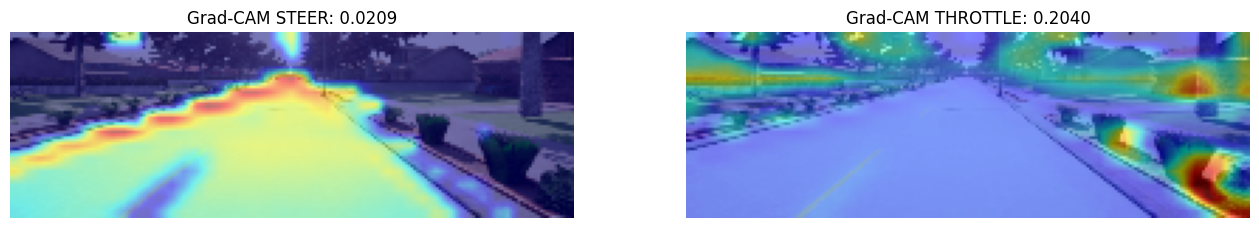

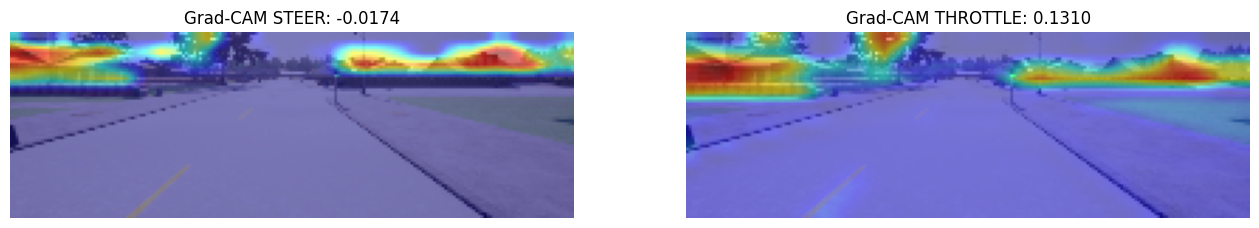

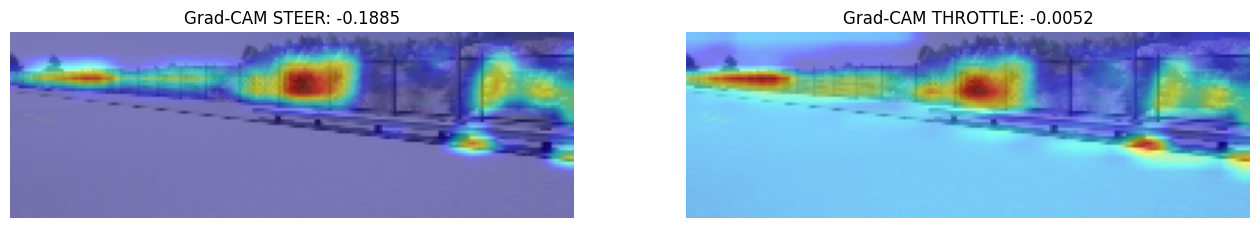

In [25]:
df_path = "/home/jrguezg/2025-tfg-jorge-rodriguez/common_utils/datasets/30K_DRUNK_DATASET"
images_list = [f for f in os.listdir(df_path) if f.endswith(".png")]
random_images = random.sample(images_list, 3)

for img_name in random_images:
    # 1. Cargar y recortar (manteniendo coherencia con entrenamiento)
    full_path = os.path.join(df_path, img_name)
    raw_img = cv2.cvtColor(cv2.imread(full_path), cv2.COLOR_BGR2RGB)
    h, w = raw_img.shape[:2]
    img_cropped = raw_img[int(h*0.35):, :] # Mismo crop que en el dataset
    
    # 2. Preparar tensor para el modelo
    img_pil = Image.fromarray(img_cropped)
    input_tensor = preprocess(img_pil).unsqueeze(0).to(device)

    # 3. Obtener predicciones reales
    with torch.no_grad():
        preds = model(input_tensor)
        p_steer, p_throt = preds[0, 0].item(), preds[0, 1].item()

    targets_steer = [CustomRegressionTarget(0)]
    grayscale_steer = cam(input_tensor=input_tensor, targets=targets_steer)[0, :]

    # Para THROTTLE
    targets_throt = [CustomRegressionTarget(1)]
    grayscale_throt = cam(input_tensor=input_tensor, targets=targets_throt)[0, :]

    # 6. Preparar imagen base para visualización (Normalizada 0-1)
    img_float = cv2.resize(img_cropped, (200, 66)).astype(np.float32) / 255
    
    vis_steer = show_cam_on_image(img_float, grayscale_steer, use_rgb=True)
    vis_throt = show_cam_on_image(img_float, grayscale_throt, use_rgb=True)

    # Visualización final
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    axes[0].imshow(vis_steer)
    axes[0].set_title(f"Grad-CAM STEER: {p_steer:.4f}")
    axes[0].axis("off")
    
    axes[1].imshow(vis_throt)
    axes[1].set_title(f"Grad-CAM THROTTLE: {p_throt:.4f}")
    axes[1].axis("off")
    
    plt.show()